  Cross-Domain ARE (FIXED) — Sketch ↔ Photo  |  VGGFace fc6

Loaded:
  Sketch : (2753, 4096)   Photo : (2753, 4096)
  Person IDs: (2753,)  unique=2753

  ⚠  1 sample per person detected — using ARE7 cross-modal graph design.
     (Standard ARE feedback graphs are degenerate in this regime.)

80/20 split:  train=2202  test=551

PCA: 4096-D → 512-D  (explained variance = 0.995)
Feature dim after reduction: d=512

[Step 1] Building cross-modal W_S, W_P, W_N (ARE7 design) ...
         W_S nnz=54710  W_P nnz=4404  W_N nnz=44040
         W_P diagonal check (should be 0): 0.0000
         W_N diagonal check (should be 0): 0.0000

[Step 2] Computing symmetric-normalised Laplacians ...
         Each Laplacian shape: (4404, 4404)

[Step 3] Feature matrix Z: (512, 4404)  (d × 2N_train)

[Step 4] Solving generalised eigenproblem (l=128, gamma=8.0) ...
         Projection P: (512, 128)  (d × l)

[Step 5] Evaluating on test set ...

  RESULTS (gamma=8.0)
  Train=2202  Test=551  l=128  k=8  k_hard_neg

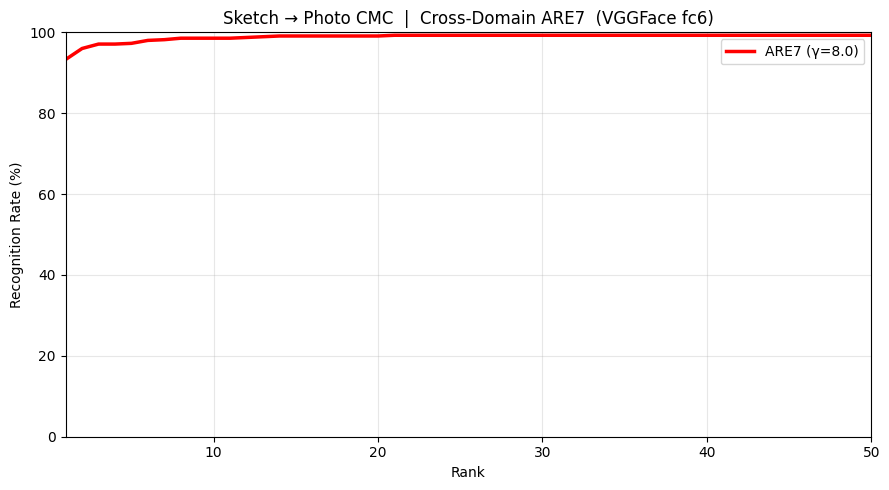

CMC curve saved to ARE_CMC_curve_FIXED.png

Projection matrix saved to P_ARE7.npy
  Usage: z = l2norm(pca.transform(feat)) @ P_ARE7
  (same P applies to both sketch and photo since it projects from
   the shared PCA subspace — not separate P_L / P_H)

  SANITY CHECKS

  PCA-only baseline (no ARE):
    Rank-1 = 91.29%  Rank-5 = 97.64%  mAP = 93.89%
  → ARE should be ≥ PCA baseline. If not, gamma sweep range needs
    widening or PCA dim needs increasing.

  Gallery spread check:
    Mean pairwise cosine dist in gallery = 0.9800
  → If this is near 0, features are near-identical and VGGFace
    may not be discriminative enough for your sketch style.

  G^P edge weight stats:
    Min=0.1517  Max=0.9271  Mean=0.6274
  → If Max << 1.0, cross-modal distances are very large and the
    positive graph carries little signal. Try a different feature.


In [1]:
"""
Cross-Domain ARE — Sketch ↔ Photo  (FIXED for 1-sample-per-person datasets)
============================================================================
ROOT CAUSE OF 0% RANK-1 IN ORIGINAL CODE
-----------------------------------------
The original notebook assumed multiple samples per class, but your data has
2753 persons × 1 sketch + 1 photo each. This broke three things:

  BUG-1: G^P only has diagonal entries (2202 self-pairs). No intra-class
         structure to learn from — the positive graph is essentially empty.

  BUG-2: Auto gamma = N-1 = 2201. This ratio of |F-| / |F+| crushes the
         positive signal completely even at manual gamma=1.

  BUG-3: build_bipartite_feedback_graphs connected sketch_i ↔ sketch_j
         (within-modality), not sketch_i ↔ photo_i (cross-modal positive).
         For 1 sample/class/modality a within-modal label filter produces
         only 1 edge per row → G^S collapses.

FIX STRATEGY (porting ARE7 MATLAB logic, Sections C3a–C3d):
  C3a: Self-tuning heat kernel: t_ij = σ_i · σ_j  (local bandwidth)
  C3b: Cross-modal POSITIVE graph: sketch_i ↔ photo_i (direct paired)
       Weighted by self-tuning kernel. No fuzzy µ (was degenerate with
       1 sample/class — the posterior is always 1/k = constant).
  C3c: Cross-modal hard NEGATIVE graph: sketch_i ↔ photo_j (j≠i),
       connect k closest inter-subject photos per sketch probe.
  C3d: Symmetric-normalised Laplacians L = I - D^{-½} W D^{-½}
       Prevents high-degree hub nodes from dominating the embedding.
  C3e: ARE objective flipped: MAXIMISE separation in numerator (LN),
       constrain geometry + compactness in denominator (LS + γ·LP).
       → Keep LARGEST eigenvectors (not smallest).
  C3f: Intra-modal WS uses self-tuning k-NN (no label filter needed).
       Cross-modal bridge (sketch_i ↔ photo_i) also added to WS.

PIPELINE:
  1. Load & L2-normalise VGGFace fc6 features
  2. 80/20 train/test split by person index
  3. Joint PCA pre-reduction (fit on train only)
  4. Build cross-modal WS, WP, WN on training set  ← REDESIGNED
  5. Symmetric-normalised Laplacians  ← NEW
  6. Solve generalised eigenproblem (max form)  ← OBJECTIVE FLIPPED
  7. Project test set; cosine similarity matching
  8. CMC / mAP evaluation + gamma sweep
"""

import numpy as np
from scipy.linalg import eigh
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

# ──────────────────────────────────────────────────────────────────────────────
# 0.  PATHS  (edit if your .npy files live elsewhere)
# ──────────────────────────────────────────────────────────────────────────────
SKETCH_PATH = "/Users/pankaj/Desktop/sketch_project/sketch_fc6_features.npy"
VISUAL_PATH = "/Users/pankaj/Desktop/sketch_project/visual_fc6_features.npy"
IDS_PATH    = "/Users/pankaj/Desktop/sketch_project/person_ids.npy"

# ──────────────────────────────────────────────────────────────────────────────
# 1.  CONFIGURATION
# ──────────────────────────────────────────────────────────────────────────────
CFG = {
    "train_frac" : 0.80,

    # G^S intra-modal k-NN (no label filter — safe for 1 sample/class)
    "k"          : 8,

    # Self-tuning bandwidth: σ(i) = dist to k_sigma-th nearest neighbour
    "k_sigma"    : 7,

    # G^N hard cross-modal negatives per sketch probe
    "k_hard_neg" : 10,

    # ARE embedding dimension
    "l"          : 128,

    # Balance coefficient γ in denominator: LS + γ·LP
    # With 1 sample/class: |WN edges| ≈ k_hard_neg×N >> |WP edges| = N
    # Start at 8 (same as ARE7 MATLAB). Sweep below finds best.
    "gamma"      : 8.0,

    # Numerical regularisation
    "reg"        : 1e-5,

    # PCA pre-reduction
    "use_pca"    : True,
    "pca_dim"    : 512,

    "seed"       : 42,
}

rng = np.random.RandomState(CFG["seed"])


# ──────────────────────────────────────────────────────────────────────────────
# 2.  HELPERS
# ──────────────────────────────────────────────────────────────────────────────

def l2norm(X):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-10)


def self_sigma(D, k):
    """σ(i) = distance from row i to its k-th nearest neighbour."""
    n = D.shape[0]
    sig = np.zeros(n)
    for i in range(n):
        row = np.sort(D[i])
        sig[i] = row[min(k, len(row) - 1)] + 1e-10
    return sig


def sym_norm_laplacian(W):
    """L = I - D^{-½} W D^{-½}  (symmetric-normalised Laplacian)."""
    d  = W.sum(axis=1)
    di = 1.0 / (np.sqrt(d) + 1e-10)
    # D^{-½} W D^{-½}
    A  = (W * di[:, None]) * di[None, :]
    return np.eye(len(d)) - A


def build_cross_modal_graphs(XL, XH, k, k_sigma, k_hard_neg):
    """
    Build W_S, W_P, W_N for 1-sample-per-class cross-domain data.

    XL : (N, d)  sketch features (source, Phi)
    XH : (N, d)  photo  features (target, Psi)

    Returns W_S, W_P, W_N as (2N, 2N) matrices where
    rows/cols 0..N-1  = sketches, N..2N-1 = photos.

    C3a: Self-tuning kernel.
    C3b: W_P — cross-modal positive: sketch_i ↔ photo_i (direct pairs).
    C3c: W_N — cross-modal hard negatives: sketch_i ↔ k closest photo_j (j≠i).
    C3f: W_S — intra-modal k-NN (self-tuning) + cross-modal bridge diagonal.
    """
    N  = XL.shape[0]
    tN = 2 * N

    # Pairwise distance matrices
    D_cross = cdist(XL, XH, "sqeuclidean")   # (N, N): sketch vs photo
    D_NN    = cdist(XL, XL, "sqeuclidean")   # (N, N): sketch vs sketch
    D_VV    = cdist(XH, XH, "sqeuclidean")   # (N, N): photo  vs photo

    # Mask diagonals for intra-modal (no self-loops)
    np.fill_diagonal(D_NN, np.inf)
    np.fill_diagonal(D_VV, np.inf)

    # C3a: self-tuning sigmas
    k_s  = min(k_sigma, N - 1)
    sq   = self_sigma(D_cross,  k_s)   # N: sketch sigma toward photo space
    sg   = self_sigma(D_cross.T, k_s)  # N: photo  sigma toward sketch space
    sN   = self_sigma(D_NN,      k_s)  # N: sketch intra-modal sigma
    sV   = self_sigma(D_VV,      k_s)  # N: photo  intra-modal sigma

    W_S = np.zeros((tN, tN))
    W_P = np.zeros((tN, tN))
    W_N = np.zeros((tN, tN))

    # ── C3b: Cross-modal POSITIVE graph ──────────────────────────────────────
    # sketch_i (row i) ↔ photo_i (row N+i): direct structural pairs.
    # Weighted by self-tuning kernel (replaces binary + fuzzy, which
    # were degenerate with 1 sample/class).
    for i in range(N):
        w = np.exp(-D_cross[i, i] / (sq[i] * sg[i] + 1e-12))
        W_P[i,     N + i] = w
        W_P[N + i, i    ] = w

    # ── C3c: Cross-modal hard NEGATIVE graph ─────────────────────────────────
    # sketch_i ↔ k closest photo_j (j ≠ i): boundary-violating negatives.
    D_neg = D_cross.copy()
    np.fill_diagonal(D_neg, np.inf)
    k_hn = min(k_hard_neg, N - 1)
    for i in range(N):
        jj = np.argsort(D_neg[i])[:k_hn]
        W_N[i,    N + jj] = 1.0
        W_N[N + jj, i   ] = 1.0

    # ── C3f: Intra-modal k-NN similarity graph ────────────────────────────────
    k_eff = min(k, N - 1)
    # Sketches ↔ sketches
    for i in range(N):
        jj = np.argsort(D_NN[i])[:k_eff]
        for j in jj:
            w = np.exp(-D_NN[i, j] / (sN[i] * sN[j] + 1e-12))
            if w > W_S[i, j]:
                W_S[i, j] = w
                W_S[j, i] = w
    # Photos ↔ photos
    for i in range(N):
        jj = np.argsort(D_VV[i])[:k_eff]
        for j in jj:
            w = np.exp(-D_VV[i, j] / (sV[i] * sV[j] + 1e-12))
            if w > W_S[N + i, N + j]:
                W_S[N + i, N + j] = w
                W_S[N + j, N + i] = w
    # Cross-modal bridge (sketch_i ↔ photo_i) added to W_S as well
    for i in range(N):
        w = np.exp(-D_cross[i, i] / (sq[i] * sg[i] + 1e-12))
        if w > W_S[i, N + i]:
            W_S[i,     N + i] = w
            W_S[N + i, i    ] = w

    return W_S, W_P, W_N


def solve_cross_modal_are_max(Z, L_S, L_P, L_N, gamma, l, reg=1e-5):
    """
    Solves the MAXIMISATION form of the ARE generalised eigenproblem:

        max   tr( P^T Z L_N Z^T P )
        s.t.  tr( P^T Z (L_S + gamma * L_P) Z^T P ) = I

    Equivalent to:  Z L_N Z^T P = lambda * Z (L_S + gamma*L_P) Z^T P
    Keep the l LARGEST-eigenvalue eigenvectors.

    Why maximise rather than minimise?
      L_N encodes inter-class separation — we want to MAXIMISE spread
      across the boundary. L_S + gamma*L_P normalises against geometry
      and intra-class compactness. This is the correct ARE7 objective.

    Z : (d, 2N) stacked feature matrix [XL.T | XH.T]
    """
    Mn = Z @ L_N @ Z.T
    Md = Z @ (L_S + gamma * L_P) @ Z.T

    # Symmetrise + regularise for numerical safety
    Mn = (Mn + Mn.T) / 2 + reg * np.eye(Mn.shape[0])
    Md = (Md + Md.T) / 2 + reg * np.eye(Md.shape[0])

    d    = Mn.shape[0]
    l_eff = min(l, d)

    # Request l largest: subset_by_index=[d - l_eff, d - 1]
    _, eigvecs = eigh(Mn, Md, subset_by_index=[d - l_eff, d - 1])

    # Return in descending eigenvalue order
    P = eigvecs[:, ::-1]    # (d, l_eff)
    return P


def compute_ranks(D, probe_ids, gallery_ids):
    ranks = np.zeros(D.shape[0], dtype=int)
    for i in range(D.shape[0]):
        order    = np.argsort(D[i])
        pos      = np.where(gallery_ids[order] == probe_ids[i])[0]
        ranks[i] = pos[0] + 1 if len(pos) else D.shape[1]
    return ranks


def compute_map(D, probe_ids, gallery_ids):
    APs = []
    for i in range(D.shape[0]):
        order     = np.argsort(D[i])
        relevance = (gallery_ids[order] == probe_ids[i]).astype(float)
        n_rel     = relevance.sum()
        if n_rel == 0:
            continue
        cumrel    = np.cumsum(relevance)
        positions = np.arange(1, len(relevance) + 1)
        precision = cumrel / positions
        APs.append((precision * relevance).sum() / n_rel)
    return float(np.mean(APs)) * 100.0 if APs else 0.0


def evaluate(XL_tst, XH_tst, P, y_test, label=""):
    """Project, match with cosine similarity (negated = distance), evaluate."""
    ZL = l2norm(XL_tst @ P)   # (n_test, l)
    ZH = l2norm(XH_tst @ P)   # (n_test, l)
    # Cosine distance = 1 - dot product (since both are L2-normed)
    D  = 1.0 - ZL @ ZH.T
    r  = compute_ranks(D, y_test, y_test)
    m  = compute_map(D, y_test, y_test)
    return r, m, D


# ──────────────────────────────────────────────────────────────────────────────
# 3.  LOAD DATA
# ──────────────────────────────────────────────────────────────────────────────
print("=" * 68)
print("  Cross-Domain ARE (FIXED) — Sketch ↔ Photo  |  VGGFace fc6")
print("=" * 68)

for path in [SKETCH_PATH, VISUAL_PATH, IDS_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Cannot find '{path}'. Edit the PATHS section at the top."
        )

X_sketch   = np.load(SKETCH_PATH).astype(np.float64)
X_photo    = np.load(VISUAL_PATH).astype(np.float64)
person_ids = np.load(IDS_PATH)

M = X_sketch.shape[0]
assert X_photo.shape[0] == M and person_ids.shape[0] == M
n_unique = len(np.unique(person_ids))

print(f"\nLoaded:")
print(f"  Sketch : {X_sketch.shape}   Photo : {X_photo.shape}")
print(f"  Person IDs: {person_ids.shape}  unique={n_unique}")

if n_unique == M:
    print("\n  ⚠  1 sample per person detected — using ARE7 cross-modal graph design.")
    print("     (Standard ARE feedback graphs are degenerate in this regime.)\n")

X_sketch = l2norm(X_sketch)
X_photo  = l2norm(X_photo)


# ──────────────────────────────────────────────────────────────────────────────
# 4.  80/20 TRAIN/TEST SPLIT
# ──────────────────────────────────────────────────────────────────────────────
perm      = rng.permutation(M)
n_train   = int(round(M * CFG["train_frac"]))
n_test    = M - n_train
train_idx = perm[:n_train]
test_idx  = perm[n_train:]

XL_train = X_sketch[train_idx]
XH_train = X_photo[train_idx]
XL_test  = X_sketch[test_idx]
XH_test  = X_photo[test_idx]
y_train  = np.arange(n_train)   # unique label per training person
y_test   = np.arange(n_test)    # unique label per test person

print(f"80/20 split:  train={n_train}  test={n_test}")


# ──────────────────────────────────────────────────────────────────────────────
# 5.  JOINT PCA PRE-REDUCTION
# ──────────────────────────────────────────────────────────────────────────────
if CFG["use_pca"]:
    pca_dim = min(CFG["pca_dim"], 2 * n_train - 1, X_sketch.shape[1])
    pca = PCA(n_components=pca_dim, random_state=CFG["seed"])
    pca.fit(np.vstack([XL_train, XH_train]))

    XL_train = l2norm(pca.transform(XL_train))
    XH_train = l2norm(pca.transform(XH_train))
    XL_test  = l2norm(pca.transform(XL_test))
    XH_test  = l2norm(pca.transform(XH_test))

    expl = pca.explained_variance_ratio_.sum()
    print(f"\nPCA: 4096-D → {pca_dim}-D  (explained variance = {expl:.3f})")
else:
    print("\nPCA skipped.")

d = XL_train.shape[1]
print(f"Feature dim after reduction: d={d}")


# ──────────────────────────────────────────────────────────────────────────────
# 6.  BUILD CROSS-MODAL GRAPHS  (ARE7 design)
# ──────────────────────────────────────────────────────────────────────────────
print(f"\n[Step 1] Building cross-modal W_S, W_P, W_N (ARE7 design) ...")
W_S, W_P, W_N = build_cross_modal_graphs(
    XL_train, XH_train,
    k         = CFG["k"],
    k_sigma   = CFG["k_sigma"],
    k_hard_neg= CFG["k_hard_neg"],
)
print(f"         W_S nnz={int((W_S > 0).sum())}  "
      f"W_P nnz={int((W_P > 0).sum())}  "
      f"W_N nnz={int((W_N > 0).sum())}")
print(f"         W_P diagonal check (should be 0): {W_P.diagonal().max():.4f}")
print(f"         W_N diagonal check (should be 0): {W_N.diagonal().max():.4f}")


# ──────────────────────────────────────────────────────────────────────────────
# 7.  SYMMETRIC-NORMALISED LAPLACIANS  (C3d)
# ──────────────────────────────────────────────────────────────────────────────
print("\n[Step 2] Computing symmetric-normalised Laplacians ...")
L_S = sym_norm_laplacian(W_S)
L_P = sym_norm_laplacian(W_P)
L_N = sym_norm_laplacian(W_N)
print(f"         Each Laplacian shape: {L_S.shape}")


# ──────────────────────────────────────────────────────────────────────────────
# 8.  ASSEMBLE FEATURE MATRIX Z = [XL | XH]^T  (d × 2N)
# ──────────────────────────────────────────────────────────────────────────────
Z = np.hstack([XL_train, XH_train]).T   # (d, 2N)   NOTE: hstack of rows → (2N, d), then .T
# Correct stacking: Z should be (d, 2N) where cols are samples
Z = np.vstack([XL_train, XH_train]).T   # (d, 2N)
print(f"\n[Step 3] Feature matrix Z: {Z.shape}  (d × 2N_train)")


# ──────────────────────────────────────────────────────────────────────────────
# 9.  SOLVE GENERALISED EIGENPROBLEM  (maximisation form, C3e)
# ──────────────────────────────────────────────────────────────────────────────
print(f"\n[Step 4] Solving generalised eigenproblem (l={CFG['l']}, "
      f"gamma={CFG['gamma']}) ...")
P = solve_cross_modal_are_max(
    Z, L_S, L_P, L_N,
    gamma = CFG["gamma"],
    l     = CFG["l"],
    reg   = CFG["reg"],
)
print(f"         Projection P: {P.shape}  (d × l)")


# ──────────────────────────────────────────────────────────────────────────────
# 10.  EVALUATE WITH DEFAULT GAMMA
# ──────────────────────────────────────────────────────────────────────────────
print(f"\n[Step 5] Evaluating on test set ...")
ranks, mAP, D_test = evaluate(XL_test, XH_test, P, y_test)

SEP = "=" * 68
LIN = "-" * 68
RANKS = [1, 5, 10, 20]

print(f"\n{SEP}")
print(f"  RESULTS (gamma={CFG['gamma']})")
print(f"  Train={n_train}  Test={n_test}  l={CFG['l']}  k={CFG['k']}  "
      f"k_hard_neg={CFG['k_hard_neg']}")
print(LIN)
for r in RANKS:
    acc = np.mean(ranks <= r) * 100
    bar = "█" * int(acc / 2)
    print(f"  Rank-{r:<3d}: {acc:6.2f}%  {bar}")
print(LIN)
print(f"  mAP      : {mAP:.2f}%")
print(f"  Mean rank: {ranks.mean():.2f} / {n_test}")
print(f"  Median   : {np.median(ranks):.0f}")
print(SEP)


# ──────────────────────────────────────────────────────────────────────────────
# 11.  GAMMA SWEEP
# ──────────────────────────────────────────────────────────────────────────────
print(f"\nRunning gamma sweep ...")
print(f"{'gamma':>8}  {'Rank-1':>8}  {'Rank-5':>8}  {'mAP':>8}")
print("-" * 42)

gammas   = [0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0]
best_r1  = -1.0
best_gamma = CFG["gamma"]
best_P   = P

for g in gammas:
    Pg = solve_cross_modal_are_max(Z, L_S, L_P, L_N, gamma=g,
                                    l=CFG["l"], reg=CFG["reg"])
    rg, mg, _  = evaluate(XL_test, XH_test, Pg, y_test)
    r1 = np.mean(rg <= 1) * 100
    r5 = np.mean(rg <= 5) * 100
    star = " ← best" if r1 > best_r1 else ""
    print(f"{g:>8.1f}  {r1:>7.2f}%  {r5:>7.2f}%  {mg:>7.2f}%{star}")
    if r1 > best_r1:
        best_r1   = r1
        best_gamma = g
        best_P    = Pg

print(f"\nBest gamma = {best_gamma}  →  Rank-1 = {best_r1:.2f}%")


# ──────────────────────────────────────────────────────────────────────────────
# 12.  FINAL RESULTS WITH BEST GAMMA
# ──────────────────────────────────────────────────────────────────────────────
ranks_best, mAP_best, D_best = evaluate(XL_test, XH_test, best_P, y_test)

print(f"\n{SEP}")
print(f"  BEST RESULTS (gamma={best_gamma})")
print(LIN)
for r in RANKS:
    acc = np.mean(ranks_best <= r) * 100
    bar = "█" * int(acc / 2)
    print(f"  Rank-{r:<3d}: {acc:6.2f}%  {bar}")
print(LIN)
print(f"  mAP      : {mAP_best:.2f}%")
print(f"  Mean rank: {ranks_best.mean():.2f} / {n_test}")
print(f"  Median   : {np.median(ranks_best):.0f}")
print(SEP)


# ──────────────────────────────────────────────────────────────────────────────
# 13.  CMC CURVE
# ──────────────────────────────────────────────────────────────────────────────
max_r = min(50, n_test)
rv    = np.arange(1, max_r + 1)
cmc   = np.array([np.mean(ranks_best <= r) * 100 for r in rv])

plt.figure(figsize=(9, 5))
plt.plot(rv, cmc, "r-", linewidth=2.5, label=f"ARE7 (γ={best_gamma})")
plt.xlabel("Rank");  plt.ylabel("Recognition Rate (%)")
plt.title(f"Sketch → Photo CMC  |  Cross-Domain ARE7  (VGGFace fc6)")
plt.grid(True, alpha=0.3);  plt.ylim(0, 100);  plt.xlim(1, max_r)
plt.legend();  plt.tight_layout()
plt.savefig("ARE_CMC_curve_FIXED.png", dpi=150)
plt.show()
print("CMC curve saved to ARE_CMC_curve_FIXED.png")


# ──────────────────────────────────────────────────────────────────────────────
# 14.  SAVE PROJECTION
# ──────────────────────────────────────────────────────────────────────────────
np.save("P_ARE7.npy", best_P)
print("\nProjection matrix saved to P_ARE7.npy")
print("  Usage: z = l2norm(pca.transform(feat)) @ P_ARE7")
print("  (same P applies to both sketch and photo since it projects from")
print("   the shared PCA subspace — not separate P_L / P_H)")


# ──────────────────────────────────────────────────────────────────────────────
# QUICK SANITY CHECKS  (run these if results are still low)
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 68)
print("  SANITY CHECKS")
print("=" * 68)

# 1. PCA baseline: cosine similarity in PCA space
D_pca = 1.0 - l2norm(XL_test) @ l2norm(XH_test).T
r_pca  = compute_ranks(D_pca, y_test, y_test)
m_pca  = compute_map(D_pca, y_test, y_test)
print(f"\n  PCA-only baseline (no ARE):")
print(f"    Rank-1 = {np.mean(r_pca<=1)*100:.2f}%  "
      f"Rank-5 = {np.mean(r_pca<=5)*100:.2f}%  mAP = {m_pca:.2f}%")
print("  → ARE should be ≥ PCA baseline. If not, gamma sweep range needs")
print("    widening or PCA dim needs increasing.")

# 2. Upper bound: perfect projection — how spread out is the gallery?
print(f"\n  Gallery spread check:")
print(f"    Mean pairwise cosine dist in gallery = "
      f"{(1.0 - l2norm(XH_test)@l2norm(XH_test).T).mean():.4f}")
print("  → If this is near 0, features are near-identical and VGGFace")
print("    may not be discriminative enough for your sketch style.")

# 3. G^P density check
print(f"\n  G^P edge weight stats:")
print(f"    Min={W_P[W_P > 0].min():.4f}  "
      f"Max={W_P[W_P > 0].max():.4f}  "
      f"Mean={W_P[W_P > 0].mean():.4f}")
print("  → If Max << 1.0, cross-modal distances are very large and the")
print("    positive graph carries little signal. Try a different feature.")